In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
import faiss

In [2]:
# The SIFT dataset vectors are stored in .fvecs format. 
# Each vector entry starts with an int32 dimension prefix followed by that many float32 components.

def read_ivecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    return data[:, 1:]

def read_fvecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    # reinterpret everything except first column as float32
    vectors = data[:, 1:].view(np.float32)

    return vectors

BASE = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_base.fvecs"
QUERY = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_query.fvecs"
TRUTH = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_groundtruth.ivecs"

base_vectors = read_fvecs(BASE)
query_vectors = read_fvecs(QUERY)
truth_vectors = read_ivecs(TRUTH)

print(f"Dimensions of base: {base_vectors.shape}    Type: {base_vectors.dtype}")
print(f"Dimensions of query: {query_vectors.shape}    Type: {query_vectors.dtype}")
print(f"Dimensions of truth: {truth_vectors.shape}    Type: {truth_vectors.dtype}")

Dimensions of base: (10000, 128)    Type: float32
Dimensions of query: (100, 128)    Type: float32
Dimensions of truth: (100, 100)    Type: int32


In [3]:
n, d = base_vectors.shape
ids = np.arange(n)

In [4]:
def base_clusters(vectors, k, seed=42):
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=seed,
        batch_size=1024,
        max_iter=100
    )
    return kmeans.fit_predict(vectors)

def generate_continuous_from_labels(labels, k, corr_strength=1.0, seed=42):
    rng = np.random.default_rng(seed)
    
    # 1. Map labels to a 0-200 signal
    # We spread k clusters across the 0-200 range
    label_means = np.linspace(20, 180, k)
    signal = label_means[labels]
    
    # 2. handle Negative Correlation (-1.0)
    # If negative, we invert the signal: high clusters get low values
    if corr_strength < 0:
        signal = 200 - signal
    
    # 3. Blend with Noise
    # This is equivalent to your 'add_noise' but on a continuous scale
    abs_corr = abs(corr_strength)
    random_noise = rng.uniform(0, 200, size=len(labels))
    
    attr = (abs_corr * signal) + ((1 - abs_corr) * random_noise)
    
    # Add small local jitter so points in same cluster aren't identical
    attr += rng.normal(0, 5, size=len(labels))
    
    return np.clip(attr, 0, 200)

In [5]:
def build_cdf(attr, bins=100):
    hist, edges = np.histogram(attr, bins=bins, density=True)
    cdf = np.cumsum(hist)
    cdf = cdf / cdf[-1]
    return edges, cdf

def get_p_global(edges, cdf, threshold):
    idx = np.searchsorted(edges, threshold)
    if idx >= len(cdf): return 1.0
    return cdf[idx]

def _nearest_clusters(q, centroids, top_L=3):
    distances = np.linalg.norm(centroids - q, axis=1)
    return np.argsort(distances)[:top_L]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from scipy.spatial.distance import jensenshannon, cdist

def _nearest_clusters(query, centroids, top_L=7):
    # Calculate Euclidean distance between query and all centroids
    distances = cdist(query.reshape(1, -1), centroids, metric='euclidean').flatten()
    return np.argsort(distances)[:top_L]

def analyze_sift_correlation(base_vectors, query_vectors, attr, n_clusters=40):
    # 1. Setup K-Means neighborhoods on the BASE vectors
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit(base_vectors)
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    cluster_to_indices = {c: np.where(labels == c)[0] for c in range(n_clusters)}
    
    results = []
    
    # We iterate through all queries
    for i in range(len(query_vectors)):
        q = query_vectors[i]
        
        # Define the threshold for this query (e.g., query attribute value)
        threshold_q = attr[i] 
        
        # 2. Retrieval (Local Neighborhood)
        neighbor_ids = _nearest_clusters(q, centroids, top_L=7)
        local_idx = np.concatenate([cluster_to_indices[c] for c in neighbor_ids])
        attr_local = attr[local_idx]
        
        # 3. Local Stats (p_q)
        # Ratio of points in the neighborhood that pass the filter (attr <= threshold)
        p_q = np.mean(attr_local <= threshold_q)
        
        # 4. Global Stats (p_global)
        # Sample randomly from the entire dataset to compare against the local neighborhood
        # Sampling 10x the size of the neighborhood for a stable baseline
        sample_size = min(len(attr), len(local_idx) * 10)
        global_sample = np.random.choice(attr, size=sample_size, replace=False)
        p_global = np.mean(global_sample <= threshold_q)
        
        # JS Divergence (Stability clipped)
        # This measures how much the local distribution differs from the global one
        eps = 1e-10
        p_dist = np.clip([p_q, 1 - p_q], eps, 1 - eps)
        q_dist = np.clip([p_global, 1 - p_global], eps, 1 - eps)
        js_div = jensenshannon(p_dist, q_dist)
        
        # Determine direction of correlation (local > global or vice versa)
        direction = p_q - p_global
        
        results.append({
            'js': js_div,
            'dir': direction,
            'p_q': p_q,
            'p_g': p_global
        })
        
    return results

# --- EXECUTION ---
# Generating attributes for different correlation levels
k_struct = 10
kmeans_struct = MiniBatchKMeans(n_clusters=k_struct, random_state=42, n_init="auto").fit(base_vectors)
labels = kmeans_struct.labels_

attr_pos = generate_continuous_from_labels(labels, k_struct, corr_strength=0.4)
attr_neg = generate_continuous_from_labels(labels, k_struct, corr_strength=-0.4)
attr_rand = generate_continuous_from_labels(labels, k_struct, corr_strength=0.0)

res_pos = analyze_sift_correlation(base_vectors, query_vectors, attr_pos)
res_neg = analyze_sift_correlation(base_vectors, query_vectors, attr_neg)
res_rand = analyze_sift_correlation(base_vectors, query_vectors, attr_rand)

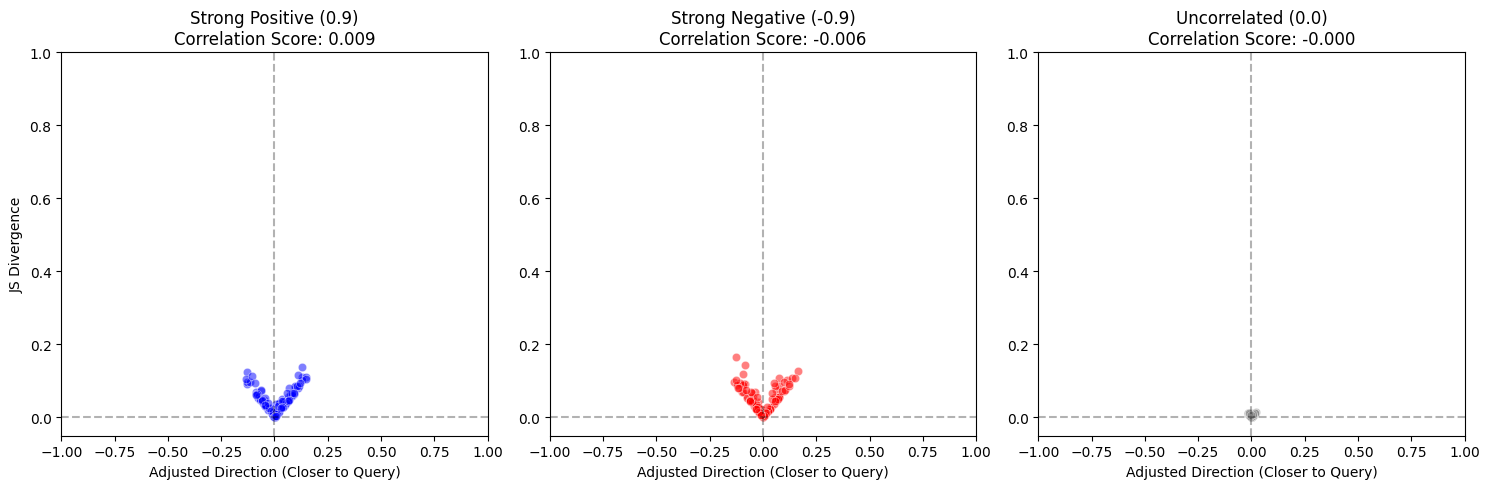

In [11]:
def plot_correlation_summary(res_pos, res_neg, res_rand):
    plt.figure(figsize=(15, 5))
    
    configs = [
        (res_pos, "Strong Positive (0.9)", "blue"),
        (res_neg, "Strong Negative (-0.9)", "red"),
        (res_rand, "Uncorrelated (0.0)", "gray")
    ]
    
    for i, (res, title, color) in enumerate(configs):
        js_vals = [r['js'] for r in res]
        dir_vals = [r['dir'] for r in res]
        
        # Score = Average of (JS * Sign of Adjusted Direction)
        # This prevents division by zero and correctly signs the correlation
        scores = [r['js'] * np.sign(r['dir']) for r in res]
        final_score = np.mean(scores)
        
        plt.subplot(1, 3, i+1)
        plt.scatter(dir_vals, js_vals, alpha=0.5, c=color, edgecolors='white', linewidth=0.5)
        
        # Quadrant lines
        plt.axvline(0, color='black', linestyle='--', alpha=0.3)
        plt.axhline(0, color='black', linestyle='--', alpha=0.3)
        
        plt.ylim(-0.05, 1.0) # JS Divergence base-e can go up to ~0.83
        plt.xlim(-1, 1)
        plt.title(f"{title}\nCorrelation Score: {final_score:.3f}")
        plt.xlabel("Adjusted Direction (Closer to Query)")
        if i == 0: plt.ylabel("JS Divergence")

    plt.tight_layout()
    plt.show()
    
plot_correlation_summary(res_pos, res_neg, res_rand)